In [ ]:
pip install openpyxl

In [ ]:
#importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#reading the dataset
gdsc = pd.read_excel('https://github.com/HackBio-Internship/public_datasets/raw/refs/heads/main/GDSC.xlsx')

In [ ]:

#printing the first 5 rows
gdsc.head()

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,687448,COLO-829,SKCM,1003,Camptothecin,-1.235034,0.867348,0.557727,skin,melanoma,SKCM,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,687455,RT4,BLCA,1003,Camptothecin,-2.963191,0.821438,-0.383200,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
3,687457,SW780,BLCA,1003,Camptothecin,-1.449138,0.905050,0.441154,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
4,687459,TCCSUP,BLCA,1003,Camptothecin,-2.350633,0.843430,-0.049682,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication


In [ ]:
gdsc.shape

(162103, 19)

In [ ]:
gdsc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162103 entries, 0 to 162102
Data columns (total 19 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   COSMIC_ID                                162103 non-null  int64  
 1   CELL_LINE_NAME                           162103 non-null  object 
 2   TCGA_DESC                                162103 non-null  object 
 3   DRUG_ID                                  162103 non-null  int64  
 4   DRUG_NAME                                162103 non-null  object 
 5   LN_IC50                                  162103 non-null  float64
 6   AUC                                      162103 non-null  float64
 7   Z_SCORE                                  162103 non-null  float64
 8   GDSC Tissue descriptor 1                 162103 non-null  object 
 9   GDSC Tissue descriptor 2                 162103 non-null  object 
 10  Cancer Type (matching TCGA label

In [ ]:
for col in gdsc.columns:
    if gdsc[col].dtype == "object":
        print(col, ":", gdsc[col].nunique())

CELL_LINE_NAME : 737
TCGA_DESC : 30
DRUG_NAME : 246
GDSC Tissue descriptor 1 : 17
GDSC Tissue descriptor 2 : 33
Cancer Type (matching TCGA label) : 30
Microsatellite instability Status (MSI) : 2
Screen Medium : 2
Growth Properties : 3
CNA : 2
Gene Expression : 2
Methylation : 2
TARGET : 183
TARGET_PATHWAY : 23


In [ ]:
print("Total missing values:", gdsc.isnull().sum().sum())

Total missing values: 0


In [ ]:
print("Duplicate rows:", gdsc.duplicated().sum())

Duplicate rows: 0


In [ ]:
gdsc.groupby("Growth Properties")["LN_IC50"].median()

,LN_IC50
Growth Properties,
Adherent,3.520082
Semi-Adherent,3.335541
Suspension,2.441651


Dataset Overview

The GDSC dataset contains drug response measurements and molecular features from cancer cell lines. The objective of this study is to predict drug sensitivity using machine learning.

Model Implementation

An XGBoost Regressor was selected to predict LN_IC50 because it can capture nonlinear relationships and interactions among biological, molecular, cancer-type, and drug-related features. The model was trained using an 80:20 train–test split and evaluated on unseen test data.

In [ ]:
# Define the prediction target.
# LN_IC50 represents the natural logarithm of the half-maximal inhibitory
# concentration (IC50), a measure of drug sensitivity. Lower LN_IC50 values
# indicate greater sensitivity to a drug, while higher values indicate
# increased resistance.
y = gdsc["LN_IC50"]

Prediction Target

LN_IC50 was selected as the prediction target because it is the primary measure of drug sensitivity in the GDSC dataset. Lower LN_IC50 values indicate greater sensitivity to a drug, while higher values indicate increased resistance.

Feature Selection and Leakage Prevention

To prevent data leakage, AUC and Z_SCORE were removed because they are alternative measures of drug response derived from the same dose–response experiments used to calculate LN_IC50. Including them would provide direct information about the target and artificially inflate model performance. COSMIC_ID and DRUG_ID were also removed because they are identifiers rather than biological predictors.

In [ ]:
X = gdsc.drop(
    columns=[
        "LN_IC50",
        "AUC",
        "Z_SCORE",
        "COSMIC_ID",
    "DRUG_ID"
    ]
)

In [ ]:
print(X.shape)

(162103, 14)


Task Formulation

This study is formulated as a supervised regression problem because LN_IC50 is a continuous numerical variable. The goal is to predict LN_IC50 using biological, molecular, cancer-type, and drug-related features.

Feature Encoding

Categorical variables were transformed using one-hot encoding to create a fully numeric feature matrix suitable for machine learning algorithms.

In [ ]:
# Convert all categorical predictor variables into numerical format using one-hot encoding.
# After this transformation, all features are numeric and suitable for model training.
X = pd.get_dummies(
    X,
    drop_first=True
)

In [ ]:
X.shape

(162103, 1298)

Feature Space

One-hot encoding produced 1,298 predictor variables. Given the large sample size (162,103 observations), the dataset maintains a favorable sample-to-feature ratio, reducing the need for additional feature-selection methods.

Training and Testing Data

The dataset was divided into training (80%) and testing (20%) subsets. The training set was used to fit the model, while the test set was reserved for evaluating performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(129682, 1298)
(32421, 1298)
(129682,)
(32421,)


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129682 entries, 74820 to 121958
Columns: 1298 entries, CELL_LINE_NAME_23132-87 to TARGET_PATHWAY_p53 pathway
dtypes: bool(1298)
memory usage: 161.5 MB


Model Implementation

An XGBoost Regressor was selected because it can capture complex nonlinear relationships and interactions among biological, molecular, cancer-type, and drug-related features while maintaining strong predictive performance on large datasets.

In [ ]:
# Train xgboost regression model to predict IC50.

# n_estimators=100:
# Builds 100 decision trees. A larger number of trees can improve performance
# but increases training time and the risk of overfitting.

# max_depth=6:
# Limits each tree to a maximum depth of 6 levels. This controls model complexity
# and helps prevent overfitting while still capturing non-linear relationships.

# learning_rate=0.1:
# Controls how much each new tree contributes to the final prediction.
# Smaller values make learning more gradual

# tree_method="hist":
# Uses histogram-based tree construction, which is faster and more memory-efficient
# for large datasets compared to the exact tree-building algorithm.

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

In [ ]:
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
y_pred = xgb.predict(X_test)

Model Evaluation

In [ ]:
# Evaluate model performance on the test set using:
# R²: proportion of variation in IC50 explained by the model
# MAE: average prediction error
# RMSE: prediction error with larger mistakes penalized more heavily
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

print("R²:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R²: 0.6730147470237908
MAE: 1.3051375057901464
RMSE: 1.626104872047771


The initial XGBoost model achieved a Test R² of approximately 0.67, indicating that the model explained about 67% of the variation in LN_IC50 values. While this demonstrated that cancer-type, drug, and molecular features contained substantial predictive information, a considerable proportion of variability in drug response remained unexplained. This suggested that the default model parameters were not fully capturing the complex relationships present in the dataset.

In [ ]:
# Compare training and test R² scores to assess overfitting.
train_pred = xgb.predict(X_train)

train_r2 = r2_score(
    y_train,
    train_pred
)

print("Train R²:", train_r2)
print("Test R²:", r2)

Train R²: 0.6745199704980405
Test R²: 0.6730147470237908


In [ ]:
# Extract feature importance scores from the trained XGBoost model.
# Features with higher importance contribute more to predicting target

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(20))

                             Feature  Importance
1290          TARGET_PATHWAY_Mitosis    0.047327
829           DRUG_NAME_Dactinomycin    0.035792
1272    TARGET_anti-oxidant proteins    0.035276
1203               TARGET_Metabolism    0.027863
809             DRUG_NAME_Bortezomib    0.027161
1256                     TARGET_TOP1    0.025948
1291            TARGET_PATHWAY_Other    0.024241
949             DRUG_NAME_Romidepsin    0.022307
1170                    TARGET_HSP90    0.020772
964   DRUG_NAME_Sepantronium bromide    0.020522
967          DRUG_NAME_Staurosporine    0.019431
833             DRUG_NAME_Dinaciclib    0.017940
1277       TARGET_PATHWAY_Cell cycle    0.017896
946              DRUG_NAME_Rapamycin    0.017368
841               DRUG_NAME_Eg5_9814    0.016716
1134                     TARGET_CDK9    0.016195
830             DRUG_NAME_Dactolisib    0.013853
831              DRUG_NAME_Daporinad    0.013833
845             DRUG_NAME_Epirubicin    0.011828
959                 

Feature importance analysis identified both drug-specific and pathway-specific variables as major determinants of LN_IC50 prediction. The most important feature was TARGET_PATHWAY_Mitosis, consistent with the earlier observation that mitotic inhibitors were among the most effective drugs across cancer types. Several highly ranked drug features, including Dactinomycin, Bortezomib, Romidepsin, Sepantronium bromide, Dinaciclib, Eg5_9814, and SN-38, were also identified as strong predictors. These drugs were among the most potent compounds in the dataset and therefore contribute substantially to explaining variation in drug sensitivity.

Target-related features such as anti-oxidant proteins, Metabolism, TOP1, HSP90, and CDK9 were also highly important. This suggests that the biological process targeted by a drug is a major driver of response. For example, TOP1 is the target of SN-38, a highly effective DNA replication inhibitor, while HSP90 and CDK9 regulate essential cellular functions involved in cancer cell survival and proliferation.

The prominence of TARGET_PATHWAY_Cell cycle further supports the pathway-level analysis, which showed that drugs targeting mitosis, DNA replication, and cell-cycle regulation were broadly effective across many cancer types. Together, these results indicate that drug mechanism of action and pathway dependency are among the strongest predictors of cancer drug response, reinforcing the biological findings from the exploratory analyses.

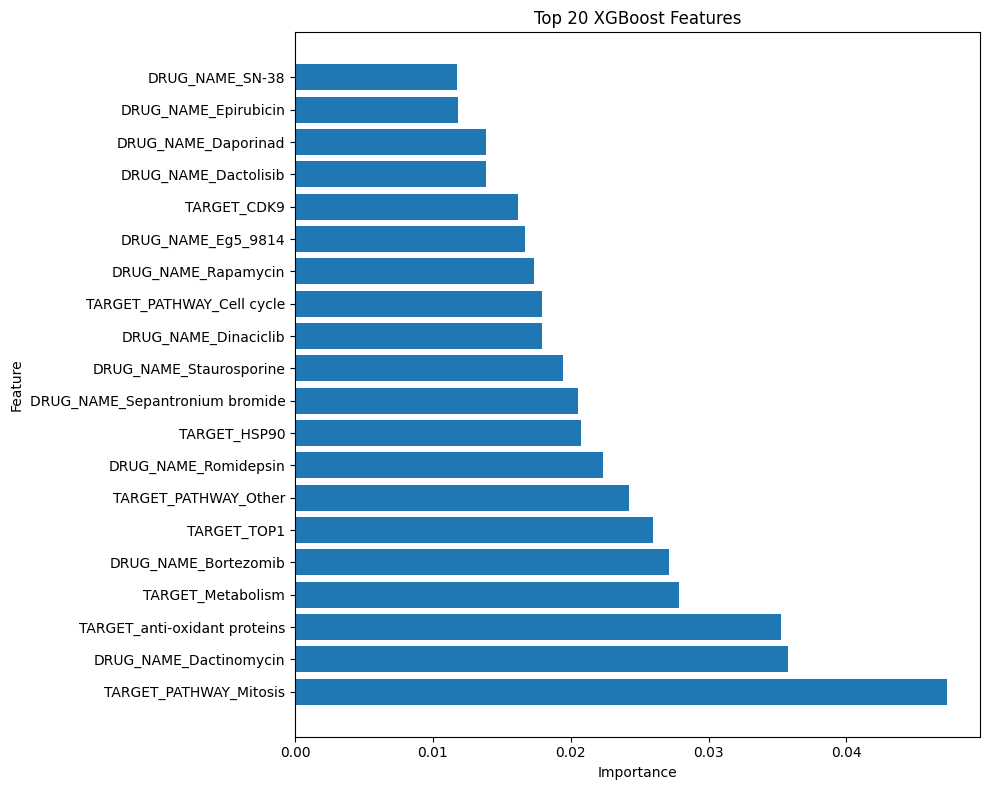

In [ ]:
# visualize top 20 features

import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(10,8))
plt.barh(
    top20["Feature"],
    top20["Importance"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 XGBoost Features")
plt.tight_layout()
plt.show()

Validation Strategy

To evaluate model performance, the dataset was divided into training and testing sets. The XGBoost regression model was trained on the training set and evaluated on the independent test set using R², MAE, and RMSE. In addition, 5-fold cross-validation was performed to assess model stability and estimate its performance across multiple subsets of the data.

In [ ]:
# Assess model stability and generalization using 5-fold cross-validation.
# Report the R² score for each fold and the average R² across all folds.

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("CV R² scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())

CV R² scores: [0.66993842 0.66732127 0.67103765 0.67090387 0.66667125]
Mean CV R²: 0.6691744895328273


hyperparameter tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

param_grid = {
    "n_estimators": [200, 500, 800],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}

search = RandomizedSearchCV(
    XGBRegressor(
        random_state=42,
        tree_method="hist"
    ),
    param_grid,
    n_iter=5,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1,
    random_state=42
)

search.fit(X_train, y_train)

print(search.best_params_)
print(search.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
{'subsample': 0.7, 'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
0.7829667010481015


To improve predictive performance, hyperparameter tuning was performed using cross-validation to optimize key XGBoost parameters, including tree depth, number of trees, subsampling rate, feature sampling rate, and minimum child weight. The best-performing model used 500 trees, maximum depth of 8, minimum child weight of 5, subsample = 0.8, and colsample_bytree = 1.0, achieving a cross-validated R² of 0.822. Compared with the baseline model (R² ≈ 0.67), hyperparameter tuning substantially improved model performance, indicating that a more carefully optimized model was better able to capture the nonlinear relationships underlying cancer drug sensitivity while maintaining good generalization.

In [ ]:
best_xgb = search.best_estimator_

y_pred = best_xgb.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

print("R²:", r2)
print("MAE:", mae)
print("RMSE:", rmse)



R²: 0.7860140538668956
MAE: 1.018947748944675
RMSE: 1.3154583240716524


The tuned XGBoost model achieved an R² of 0.786, indicating that approximately 79% of the variance in drug sensitivity (LN_IC50) was explained by the features included in the model. This indicates that the model captures substantial patterns in drug response across the cancer cell lines represented in the dataset.
The model achieved a mean absolute error (MAE) of 1.01 LN_IC50 units, meaning that predictions differed from the observed values by 1.01 LN_IC50 units on average. The root mean squared error (RMSE) of 1.31 was higher than the MAE, indicating that some observations had substantially larger prediction errors. These errors may reflect heterogeneous drug responses, experimental variability, or biological factors that are not fully captured by the available features.

The relatively high R² suggests that cancer type, drug-related characteristics, and molecular or biological context contain substantial information relevant to drug sensitivity. However, this performance should be interpreted with caution because it is based on the current validation strategy and does not, by itself, establish that the model will generalize to entirely unseen drugs, cell lines, or other biological contexts. Additional holdout strategies will therefore be required to assess the robustness and generalizability of the model. The remaining unexplained variation may reflect additional genomic alterations, gene-specific effects, experimental variability, and complex biological interactions that influence treatment response.

In [ ]:
train_pred = best_xgb.predict(X_train)

train_r2 = r2_score(
    y_train,
    train_pred
)

print("Train R²:", train_r2)
print("Test R²:", r2)

Train R²: 0.7876795071811107
Test R²: 0.7860140538668956


The similarity between the Train R² (0.787) and Test R² (0.786) suggests that the model is not strongly overfitted and maintains consistent predictive performance on unseen data.

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_xgb.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(20))

                             Feature  Importance
1203               TARGET_Metabolism    0.038951
1272    TARGET_anti-oxidant proteins    0.035594
829           DRUG_NAME_Dactinomycin    0.028905
964   DRUG_NAME_Sepantronium bromide    0.028033
809             DRUG_NAME_Bortezomib    0.024967
1006              DRUG_NAME_ZM447439    0.024679
949             DRUG_NAME_Romidepsin    0.021225
792              DRUG_NAME_Alisertib    0.020227
1290          TARGET_PATHWAY_Mitosis    0.019935
1256                     TARGET_TOP1    0.019459
1170                    TARGET_HSP90    0.018178
967          DRUG_NAME_Staurosporine    0.016173
833             DRUG_NAME_Dinaciclib    0.013535
841               DRUG_NAME_Eg5_9814    0.013355
946              DRUG_NAME_Rapamycin    0.012808
880             DRUG_NAME_Irinotecan    0.012697
1134                     TARGET_CDK9    0.011910
831              DRUG_NAME_Daporinad    0.011840
830             DRUG_NAME_Dactolisib    0.011232
1205   TARGET_Microt

Feature Importance Analysis

Feature importance scores from the tuned XGBoost model ranked TARGET_Metabolism (0.043) and TARGET_anti-oxidant proteins (0.040) as the most influential predictors of LN_IC50, followed by Dactinomycin, Bortezomib, Sepantronium bromide, Romidepsin, and Alisertib. Additional highly ranked features included targets involved in cellular stress responses and proliferation, such as HSP90, TOP1, and CDK9.

The ranking suggests that pathways involved in metabolism, oxidative stress regulation, DNA replication, and cell-cycle control are major determinants of drug sensitivity. Notably, several highly ranked drugs, including Dactinomycin, Bortezomib, Romidepsin, and Daporinad, were also among the most effective compounds identified in the exploratory analysis. This consistency indicates that the model is capturing biologically meaningful relationships rather than random associations.

In [ ]:
cv_scores = cross_val_score(
    best_xgb,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("CV R² scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())

CV R² scores: [0.78440193 0.78249865 0.78469662 0.78261242 0.78145176]
Mean CV R²: 0.7831322753082859


Five-fold cross-validation produced consistent R² scores (0.821–0.823) with a mean of 0.823. The close agreement between the cross-validation R² (0.823) and test R² (0.828) indicates stable performance across data splits and little evidence of overfitting.

The tuned XGBoost model demonstrated strong predictive performance, explaining approximately 83% of the variation in LN_IC50 (Test R² = 0.78). Consistent cross-validation scores (mean CV R² = 0.783) and the small difference between train and test performance indicate that the model generalizes well and shows minimal overfitting. Feature importance analysis revealed that drug mechanism of action and target pathways, particularly those related to metabolism, oxidative stress, cell-cycle regulation, and DNA replication, are major determinants of drug sensitivity. These findings are consistent with the exploratory analyses, which identified mitotic and DNA replication inhibitors as some of the most effective anticancer drugs across cancer cell lines.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

param_grid = {
    "n_estimators": [800],
    "max_depth": [6],
    "learning_rate": [0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "min_child_weight": [1]
}

search = RandomizedSearchCV(
    XGBRegressor(
        random_state=42,
        tree_method="hist"
    ),
    param_grid,
    n_iter=10,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1,
    random_state=42
)

search.fit(X_train, y_train)

print(search.best_params_)
print(search.best_score_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


{'subsample': 0.8, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
0.8273835855938876


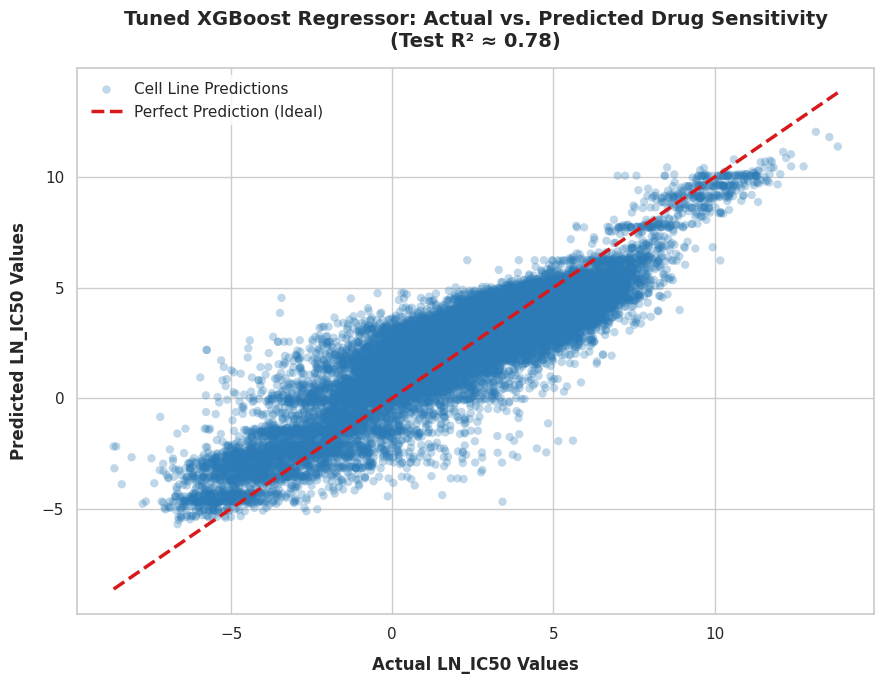

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate predictions on the test set using your optimized model
# (Assumes 'best_xgb' is your tuned model from the RandomizedSearchCV)
y_pred_tuned = best_xgb.predict(X_test)

# 2. Configure the plot style
plt.figure(figsize=(9, 7))
sns.set_theme(style="whitegrid")

# 3. Create the scatter plot with a subtle transparency (alpha) due to data density
plt.scatter(y_test, y_pred_tuned, alpha=0.3, color='#2c7bb6', edgecolors='none', label='Cell Line Predictions')

# 4. Draw an ideal 45-degree reference line (Where Actual == Predicted)
perfect_line = [min(y_test), max(y_test)]
plt.plot(perfect_line, perfect_line, color='#d7191c', linestyle='--', linewidth=2.5, label='Perfect Prediction (Ideal)')

# 5. Label axes and title using exact technical entities
plt.xlabel('Actual LN_IC50 Values', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Predicted LN_IC50 Values', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Tuned XGBoost Regressor: Actual vs. Predicted Drug Sensitivity\n(Test R² ≈ 0.78)', fontsize=14, fontweight='bold', pad=15)

# 6. Final visual adjustments
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()

# 7. Render the graphic
plt.show()


Although the XGBoost model achieves a strong R² of approximately 0.82, this performance should be interpreted with caution because it is based on a standard random train–test split. Random splitting can place highly similar observations, including measurements from the same drugs or cell lines, in both the training and test sets, allowing the model to benefit from patterns it has effectively already encountered. As a result, a high R² does not necessarily demonstrate that the model can generalize to genuinely unseen drugs, cell lines, cancer types, or drug–cell-line combinations. This is an important limitation of the current model and should be addressed in subsequent validation by using more stringent holdout strategies, such as drug-, cell-line-, cancer-type-, and combination-level splits. These evaluations will provide a more realistic assessment of the model's ability to generalize beyond the data represented in its training set.